# FraudShield BI: Quantifying the Impact of False Positives

**MIS581 Capstone — Business Intelligence and Data Analytics**  
**Author:** Atta Febri-Yeboah  
**Institution:** Colorado State University Global

This notebook contains the reproducible Python workflow used to prepare the Sparkov credit-card transaction data, conduct exploratory and statistical analysis, compare classification models, evaluate threshold tradeoffs, quantify false-positive burden, and export the validated tables and figures used in the Power BI dashboard, final paper, and presentation.

> **Data requirement:** Download `fraudTrain.csv` and `fraudTest.csv` from the Kaggle dataset referenced in `../data/README.md`, place both files in `../data/`, and run this notebook from the `notebooks/` directory.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, chi2_contingency

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

pd.set_option("display.max_columns", None)

print("FraudShield environment is ready.")

FraudShield environment is ready.


## 1. Load the Data

        Import the public simulated training and testing files and confirm that they are available at the expected relative paths.


In [3]:
train_path = "../data/fraudTrain.csv"
test_path = "../data/fraudTest.csv"

fraud_train = pd.read_csv(train_path)
fraud_test = pd.read_csv(test_path)

print("Training data shape:", fraud_train.shape)
print("Testing data shape:", fraud_test.shape)

Training data shape: (1296675, 23)
Testing data shape: (555719, 23)


## 2. Validate and Prepare the Data

        Review record counts, field structure, missing values, duplicates, and data types before feature engineering and modeling.


In [5]:
print("Training records:", len(fraud_train))
print("Testing records:", len(fraud_test))

print("\nColumn names:")
print(fraud_train.columns.tolist())

print("\nMissing values in training data:")
print(fraud_train.isnull().sum().sort_values(ascending=False).head(10))

print("\nDuplicate rows in training data:")
print(fraud_train.duplicated().sum())

fraud_distribution = (
    fraud_train["is_fraud"]
    .value_counts()
    .rename_axis("is_fraud")
    .reset_index(name="transaction_count")
)

fraud_distribution["percentage"] = (
    fraud_distribution["transaction_count"] / len(fraud_train) * 100
)

print("\nFraud distribution:")
print(fraud_distribution)

fraud_rate = fraud_train["is_fraud"].mean() * 100
print(f"\nOverall fraud rate: {fraud_rate:.4f}%")

Training records: 1296675
Testing records: 555719

Column names:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

Missing values in training data:
Unnamed: 0    0
zip           0
merch_long    0
merch_lat     0
unix_time     0
trans_num     0
dob           0
job           0
city_pop      0
long          0
dtype: int64

Duplicate rows in training data:
0

Fraud distribution:
   is_fraud  transaction_count  percentage
0         0            1289169   99.421135
1         1               7506    0.578865

Overall fraud rate: 0.5789%


In [7]:
# Remove the unnecessary CSV index column
for df in [fraud_train, fraud_test]:
    if "Unnamed: 0" in df.columns:
        df.drop(columns=["Unnamed: 0"], inplace=True)

print("Training columns after cleanup:", fraud_train.shape[1])
print("Testing columns after cleanup:", fraud_test.shape[1])
print("Unnamed column still present:", "Unnamed: 0" in fraud_train.columns)

Training columns after cleanup: 22
Testing columns after cleanup: 22
Unnamed column still present: False


## 3. Exploratory Data Analysis

        Summarize the severe class imbalance and compare transaction amounts, categories, and time-of-day patterns.


In [9]:
amount_summary = (
    fraud_train
    .groupby("is_fraud")["amt"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .rename(index={0: "Legitimate", 1: "Fraudulent"})
)

print(amount_summary)

legitimate_amounts = fraud_train.loc[
    fraud_train["is_fraud"] == 0, "amt"
]

fraudulent_amounts = fraud_train.loc[
    fraud_train["is_fraud"] == 1, "amt"
]

amount_test = mannwhitneyu(
    legitimate_amounts,
    fraudulent_amounts,
    alternative="two-sided"
)

print("\nMann-Whitney U statistic:", amount_test.statistic)
print("P-value:", amount_test.pvalue)

if amount_test.pvalue < 0.05:
    print("Reject the null hypothesis: transaction amounts differ significantly.")
else:
    print("Fail to reject the null hypothesis.")

              count        mean   median         std   min       max
is_fraud                                                            
Legitimate  1289169   67.667110   47.280  154.007971  1.00  28948.90
Fraudulent     7506  531.320092  396.505  390.560070  1.06   1376.04

Mann-Whitney U statistic: 1600757645.5
P-value: 0.0
Reject the null hypothesis: transaction amounts differ significantly.


In [11]:
# Convert date fields
for df in [fraud_train, fraud_test]:
    df["trans_date_trans_time"] = pd.to_datetime(
        df["trans_date_trans_time"],
        errors="coerce"
    )
    df["dob"] = pd.to_datetime(
        df["dob"],
        errors="coerce"
    )

# Create useful analysis features
for df in [fraud_train, fraud_test]:
    df["transaction_hour"] = df["trans_date_trans_time"].dt.hour
    df["transaction_day"] = df["trans_date_trans_time"].dt.day_name()
    df["transaction_month"] = df["trans_date_trans_time"].dt.month

    df["customer_age"] = (
        df["trans_date_trans_time"].dt.year
        - df["dob"].dt.year
    )

print(
    fraud_train[
        [
            "trans_date_trans_time",
            "transaction_hour",
            "transaction_day",
            "transaction_month",
            "customer_age"
        ]
    ].head()
)

  trans_date_trans_time  transaction_hour transaction_day  transaction_month  \
0   2019-01-01 00:00:18                 0         Tuesday                  1   
1   2019-01-01 00:00:44                 0         Tuesday                  1   
2   2019-01-01 00:00:51                 0         Tuesday                  1   
3   2019-01-01 00:01:16                 0         Tuesday                  1   
4   2019-01-01 00:03:06                 0         Tuesday                  1   

   customer_age  
0            31  
1            41  
2            57  
3            52  
4            33  


In [13]:
# Fraud rate by transaction category
category_analysis = (
    fraud_train
    .groupby("category")
    .agg(
        total_transactions=("is_fraud", "size"),
        fraudulent_transactions=("is_fraud", "sum")
    )
    .reset_index()
)

category_analysis["fraud_rate_percent"] = (
    category_analysis["fraudulent_transactions"]
    / category_analysis["total_transactions"]
    * 100
)

category_analysis = category_analysis.sort_values(
    "fraud_rate_percent",
    ascending=False
)

print("Top categories by fraud rate:")
print(category_analysis.head(10))

Top categories by fraud rate:
         category  total_transactions  fraudulent_transactions  \
11   shopping_net               97543                     1713   
8        misc_net               63287                      915   
4     grocery_pos              123638                     1743   
12   shopping_pos              116672                      843   
2   gas_transport              131659                      618   
9        misc_pos               79655                      250   
3     grocery_net               45452                      134   
13         travel               40507                      116   
0   entertainment               94014                      233   
10  personal_care               90758                      220   

    fraud_rate_percent  
11            1.756149  
8             1.445795  
4             1.409761  
12            0.722538  
2             0.469394  
9             0.313853  
3             0.294817  
13            0.286370  
0             0.24

In [15]:
# Fraud rate by hour
hour_analysis = (
    fraud_train
    .groupby("transaction_hour")
    .agg(
        total_transactions=("is_fraud", "size"),
        fraudulent_transactions=("is_fraud", "sum")
    )
    .reset_index()
)

hour_analysis["fraud_rate_percent"] = (
    hour_analysis["fraudulent_transactions"]
    / hour_analysis["total_transactions"]
    * 100
)

print("Fraud rate by hour:")
print(hour_analysis)

Fraud rate by hour:
    transaction_hour  total_transactions  fraudulent_transactions  \
0                  0               42502                      635   
1                  1               42869                      658   
2                  2               42656                      625   
3                  3               42769                      609   
4                  4               41863                       46   
5                  5               42171                       60   
6                  6               42300                       40   
7                  7               42203                       56   
8                  8               42505                       49   
9                  9               42185                       47   
10                10               42271                       40   
11                11               42082                       42   
12                12               65257                       67   
13            

## 4. Statistical Association Tests

        Test whether transaction category and transaction hour are associated with fraud status in the simulated dataset.


In [17]:
# Chi-square test: transaction category and fraud classification
category_table = pd.crosstab(
    fraud_train["category"],
    fraud_train["is_fraud"]
)

category_chi2, category_p, category_dof, category_expected = chi2_contingency(
    category_table
)

print("Category and fraud chi-square test")
print("Chi-square statistic:", category_chi2)
print("Degrees of freedom:", category_dof)
print("P-value:", category_p)

if category_p < 0.05:
    print("Reject the null hypothesis: transaction category is associated with fraud classification.")
else:
    print("Fail to reject the null hypothesis.")

Category and fraud chi-square test
Chi-square statistic: 6486.003269983207
Degrees of freedom: 13
P-value: 0.0
Reject the null hypothesis: transaction category is associated with fraud classification.


In [19]:
# Chi-square test: transaction hour and fraud classification
hour_table = pd.crosstab(
    fraud_train["transaction_hour"],
    fraud_train["is_fraud"]
)

hour_chi2, hour_p, hour_dof, hour_expected = chi2_contingency(
    hour_table
)

print("Transaction hour and fraud chi-square test")
print("Chi-square statistic:", hour_chi2)
print("Degrees of freedom:", hour_dof)
print("P-value:", hour_p)

if hour_p < 0.05:
    print("Reject the null hypothesis: transaction hour is associated with fraud classification.")
else:
    print("Fail to reject the null hypothesis.")

Transaction hour and fraud chi-square test
Chi-square statistic: 18243.563657092865
Degrees of freedom: 23
P-value: 0.0
Reject the null hypothesis: transaction hour is associated with fraud classification.


## 5. Export Descriptive Outputs and Figures

        Save validated summary tables and the first three figures used in the written report.


In [21]:
fraud_distribution.to_csv(
    "../outputs/tables/fraud_distribution.csv",
    index=False
)

amount_summary.to_csv(
    "../outputs/tables/transaction_amount_summary.csv"
)

category_analysis.to_csv(
    "../outputs/tables/fraud_by_category.csv",
    index=False
)

hour_analysis.to_csv(
    "../outputs/tables/fraud_by_hour.csv",
    index=False
)

print("Tables saved successfully.")

Tables saved successfully.


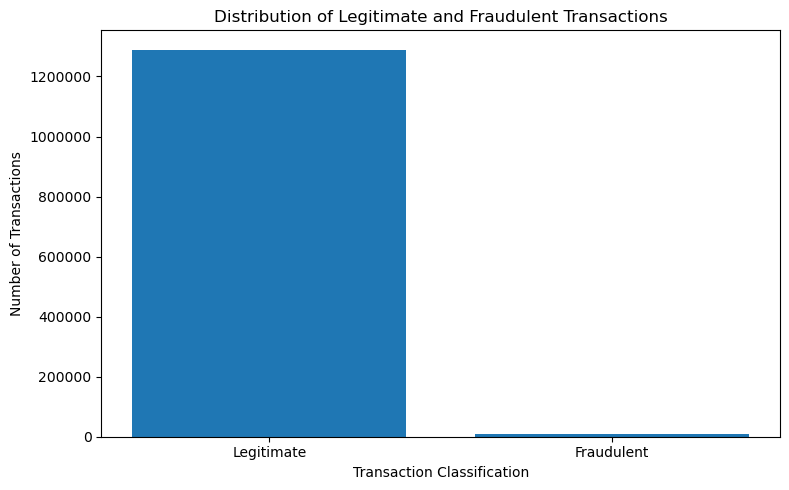

In [23]:
# Figure 1: Transaction class distribution
class_counts = fraud_train["is_fraud"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(
    ["Legitimate", "Fraudulent"],
    class_counts.values
)

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Classification")
plt.ylabel("Number of Transactions")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()

plt.savefig(
    "../outputs/charts/figure_1_transaction_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

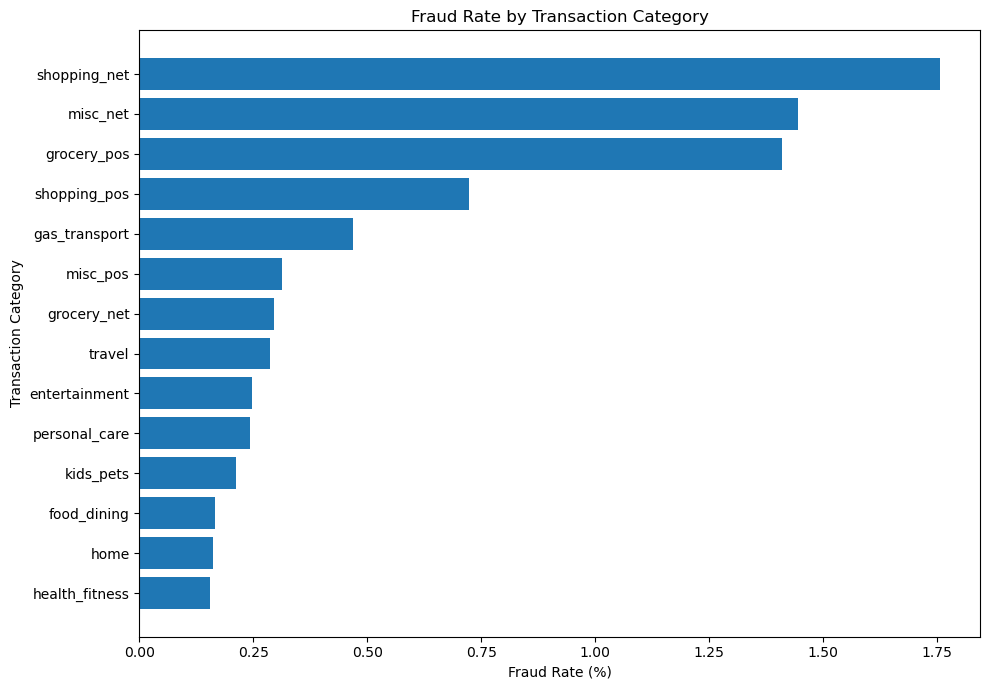

In [25]:
# Figure 2: Fraud rate by category
category_chart = category_analysis.sort_values(
    "fraud_rate_percent",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    category_chart["category"],
    category_chart["fraud_rate_percent"]
)

plt.title("Fraud Rate by Transaction Category")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Transaction Category")
plt.tight_layout()

plt.savefig(
    "../outputs/charts/figure_2_fraud_rate_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

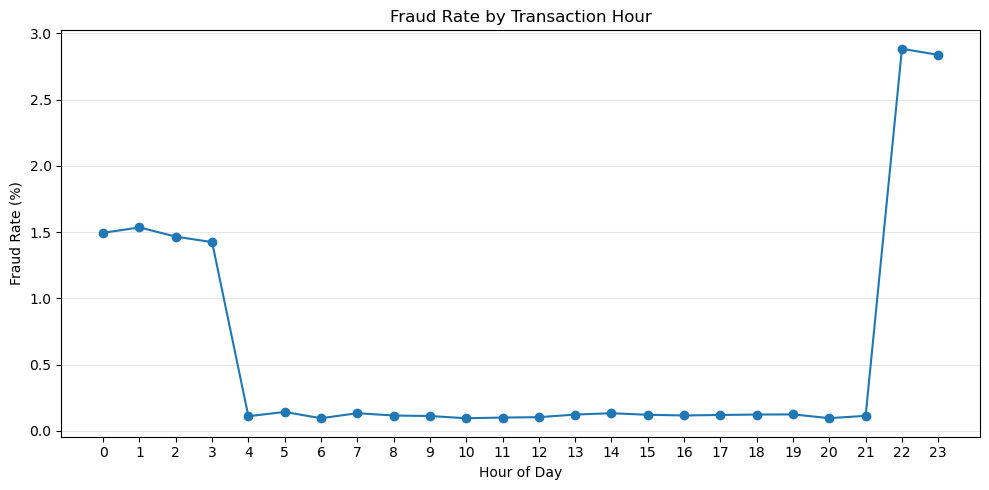

In [27]:
# Figure 3: Fraud rate by transaction hour
plt.figure(figsize=(10, 5))
plt.plot(
    hour_analysis["transaction_hour"],
    hour_analysis["fraud_rate_percent"],
    marker="o"
)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(0, 24))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../outputs/charts/figure_3_fraud_rate_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Feature Engineering

        Create business-readable features including customer age, transaction hour, and customer-to-merchant distance. Direct identifiers and high-cardinality fields are excluded from model training.


In [29]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the distance in miles between two geographic coordinates.
    """
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    delta_lat = lat2 - lat1
    delta_lon = lon2 - lon1

    a = (
        np.sin(delta_lat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2)
        * np.sin(delta_lon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return 3958.8 * c


for df in [fraud_train, fraud_test]:
    df["customer_merchant_distance"] = haversine_distance(
        df["lat"],
        df["long"],
        df["merch_lat"],
        df["merch_long"]
    )

print(
    fraud_train[
        [
            "amt",
            "transaction_hour",
            "customer_age",
            "city_pop",
            "customer_merchant_distance",
            "category",
            "gender",
            "is_fraud"
        ]
    ].head()
)

print("\nDistance summary:")
print(fraud_train["customer_merchant_distance"].describe())

      amt  transaction_hour  customer_age  city_pop  \
0    4.97                 0            31      3495   
1  107.23                 0            41       149   
2  220.11                 0            57      4154   
3   45.00                 0            52      1939   
4   41.96                 0            33        99   

   customer_merchant_distance       category gender  is_fraud  
0                   48.838809       misc_net      F         0  
1                   18.773185    grocery_pos      F         0  
2                   67.236892  entertainment      M         0  
3                   59.449252  gas_transport      M         0  
4                   48.192064       misc_pos      M         0  

Distance summary:
count    1.296675e+06
mean     4.729598e+01
std      1.809263e+01
min      1.382847e-02
25%      3.438390e+01
50%      4.861150e+01
75%      6.120778e+01
max      9.452228e+01
Name: customer_merchant_distance, dtype: float64


## 7. Class-Weighted Logistic Regression

        Build an interpretable baseline model using numeric and categorical predictors, with balanced class weights to address the rare fraud class.


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [33]:
numeric_features = [
    "amt",
    "transaction_hour",
    "customer_age",
    "city_pop",
    "customer_merchant_distance"
]

categorical_features = [
    "category",
    "gender"
]

model_features = numeric_features + categorical_features

X_train = fraud_train[model_features].copy()
y_train = fraud_train["is_fraud"].copy()

X_test = fraud_test[model_features].copy()
y_test = fraud_test["is_fraud"].copy()

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining fraud count:")
print(y_train.value_counts())

print("\nTesting fraud count:")
print(y_test.value_counts())

Training feature shape: (1296675, 7)
Testing feature shape: (555719, 7)

Training fraud count:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Testing fraud count:
is_fraud
0    553574
1      2145
Name: count, dtype: int64


In [35]:
# Preprocessing for numeric and categorical variables
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

# Class-weighted logistic regression
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                solver="liblinear",
                random_state=42
            )
        )
    ]
)

print("Training logistic regression model...")
logistic_model.fit(X_train, y_train)
print("Model training complete.")

Training logistic regression model...
Model training complete.


In [37]:
# Generate predictions and fraud probabilities
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

default_threshold = 0.50
logistic_predictions = (
    logistic_probabilities >= default_threshold
).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(
    y_test,
    logistic_predictions
).ravel()

# Performance metrics
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

logistic_pr_auc = average_precision_score(
    y_test,
    logistic_probabilities
)

print("Logistic Regression Results at Threshold 0.50")
print("---------------------------------------------")
print("True negatives:", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives:", tp)

print(f"\nAccuracy:  {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")
print(f"F1-score:  {logistic_f1:.4f}")
print(f"ROC-AUC:   {logistic_roc_auc:.4f}")
print(f"PR-AUC:    {logistic_pr_auc:.4f}")

Logistic Regression Results at Threshold 0.50
---------------------------------------------
True negatives: 486370
False positives: 67204
False negatives: 556
True positives: 1589

Accuracy:  0.8781
Precision: 0.0231
Recall:    0.7408
F1-score:  0.0448
ROC-AUC:   0.9077
PR-AUC:    0.1206


## 8. Logistic Regression Threshold Analysis

        Compare multiple decision thresholds to measure changes in precision, recall, false positives, false negatives, and manual-review volume.


In [39]:
thresholds = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

threshold_results = []

for threshold in thresholds:
    predictions = (
        logistic_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    review_volume = tp + fp

    false_positive_rate = fp / (fp + tn)

    threshold_results.append({
        "threshold": threshold,
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "false_positive_rate": false_positive_rate,
        "manual_review_volume": review_volume
    })

threshold_table = pd.DataFrame(threshold_results)

print(
    threshold_table[
        [
            "threshold",
            "false_positives",
            "false_negatives",
            "true_positives",
            "precision",
            "recall",
            "f1_score",
            "false_positive_rate",
            "manual_review_volume"
        ]
    ].to_string(index=False)
)

 threshold  false_positives  false_negatives  true_positives  precision   recall  f1_score  false_positive_rate  manual_review_volume
       0.1           380556                0            2145   0.005605 1.000000  0.011147             0.687453                382701
       0.2           274242               72            2073   0.007502 0.966434  0.014889             0.495403                276315
       0.3           170514              286            1859   0.010785 0.866667  0.021304             0.308024                172373
       0.4           114263              489            1656   0.014286 0.772028  0.028053             0.206410                115919
       0.5            67204              556            1589   0.023098 0.740793  0.044800             0.121400                 68793
       0.6            24858              585            1560   0.059051 0.727273  0.109232             0.044905                 26418
       0.7            10062              599            1546  

In [41]:
threshold_table.to_csv(
    "../outputs/tables/logistic_threshold_analysis.csv",
    index=False
)

print("Threshold analysis saved successfully.")

Threshold analysis saved successfully.


## 9. Cost-Scenario Analysis

        Estimate business impact under low-, moderate-, and high-cost assumptions. These are scenario assumptions rather than actual institutional costs.


In [43]:
# Scenario-based cost assumptions
cost_scenarios = {
    "Low Cost": {
        "false_positive_cost": 5,
        "false_negative_multiplier": 1.0
    },
    "Moderate Cost": {
        "false_positive_cost": 15,
        "false_negative_multiplier": 1.5
    },
    "High Cost": {
        "false_positive_cost": 30,
        "false_negative_multiplier": 2.0
    }
}

# Actual dollar value of fraudulent transactions missed at each threshold
cost_results = []

for threshold in thresholds:
    predictions = (
        logistic_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    false_negative_mask = (
        (y_test.values == 1) &
        (predictions == 0)
    )

    missed_fraud_amount = fraud_test.loc[
        false_negative_mask,
        "amt"
    ].sum()

    for scenario_name, assumptions in cost_scenarios.items():
        false_positive_cost = (
            fp * assumptions["false_positive_cost"]
        )

        false_negative_cost = (
            missed_fraud_amount
            * assumptions["false_negative_multiplier"]
        )

        total_cost = (
            false_positive_cost
            + false_negative_cost
        )

        cost_results.append({
            "scenario": scenario_name,
            "threshold": threshold,
            "false_positives": fp,
            "false_negatives": fn,
            "missed_fraud_amount": missed_fraud_amount,
            "estimated_false_positive_cost": false_positive_cost,
            "estimated_false_negative_cost": false_negative_cost,
            "estimated_total_cost": total_cost
        })

cost_table = pd.DataFrame(cost_results)

print(
    cost_table[
        [
            "scenario",
            "threshold",
            "false_positives",
            "false_negatives",
            "missed_fraud_amount",
            "estimated_false_positive_cost",
            "estimated_false_negative_cost",
            "estimated_total_cost"
        ]
    ].to_string(index=False)
)

     scenario  threshold  false_positives  false_negatives  missed_fraud_amount  estimated_false_positive_cost  estimated_false_negative_cost  estimated_total_cost
     Low Cost        0.1           380556                0                 0.00                        1902780                          0.000           1902780.000
Moderate Cost        0.1           380556                0                 0.00                        5708340                          0.000           5708340.000
    High Cost        0.1           380556                0                 0.00                       11416680                          0.000          11416680.000
     Low Cost        0.2           274242               72              1837.45                        1371210                       1837.450           1373047.450
Moderate Cost        0.2           274242               72              1837.45                        4113630                       2756.175           4116386.175
    High Cost   

In [45]:
best_cost_thresholds = (
    cost_table
    .loc[
        cost_table.groupby("scenario")[
            "estimated_total_cost"
        ].idxmin()
    ]
    .sort_values("scenario")
)

print("Lowest-cost threshold by scenario:")
print(
    best_cost_thresholds[
        [
            "scenario",
            "threshold",
            "false_positives",
            "false_negatives",
            "missed_fraud_amount",
            "estimated_total_cost"
        ]
    ].to_string(index=False)
)

Lowest-cost threshold by scenario:
     scenario  threshold  false_positives  false_negatives  missed_fraud_amount  estimated_total_cost
    High Cost        0.8             6802              748             78187.67            360435.340
     Low Cost        0.7            10062              599             32055.03             82365.030
Moderate Cost        0.7            10062              599             32055.03            199012.545


In [47]:
cost_table.to_csv(
    "../outputs/tables/cost_scenario_analysis.csv",
    index=False
)

best_cost_thresholds.to_csv(
    "../outputs/tables/best_threshold_by_cost_scenario.csv",
    index=False
)

print("Cost scenario tables saved successfully.")

Cost scenario tables saved successfully.


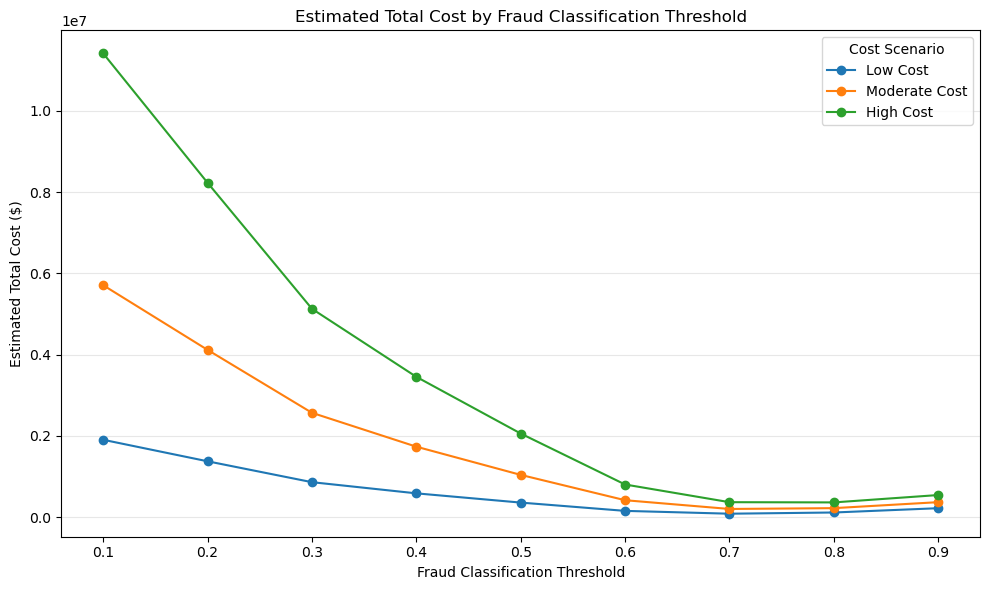

In [49]:
plt.figure(figsize=(10, 6))

for scenario_name in cost_table["scenario"].unique():
    scenario_data = cost_table[
        cost_table["scenario"] == scenario_name
    ]

    plt.plot(
        scenario_data["threshold"],
        scenario_data["estimated_total_cost"],
        marker="o",
        label=scenario_name
    )

plt.title("Estimated Total Cost by Fraud Classification Threshold")
plt.xlabel("Fraud Classification Threshold")
plt.ylabel("Estimated Total Cost ($)")
plt.xticks(thresholds)
plt.legend(title="Cost Scenario")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../outputs/charts/figure_4_total_cost_by_threshold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

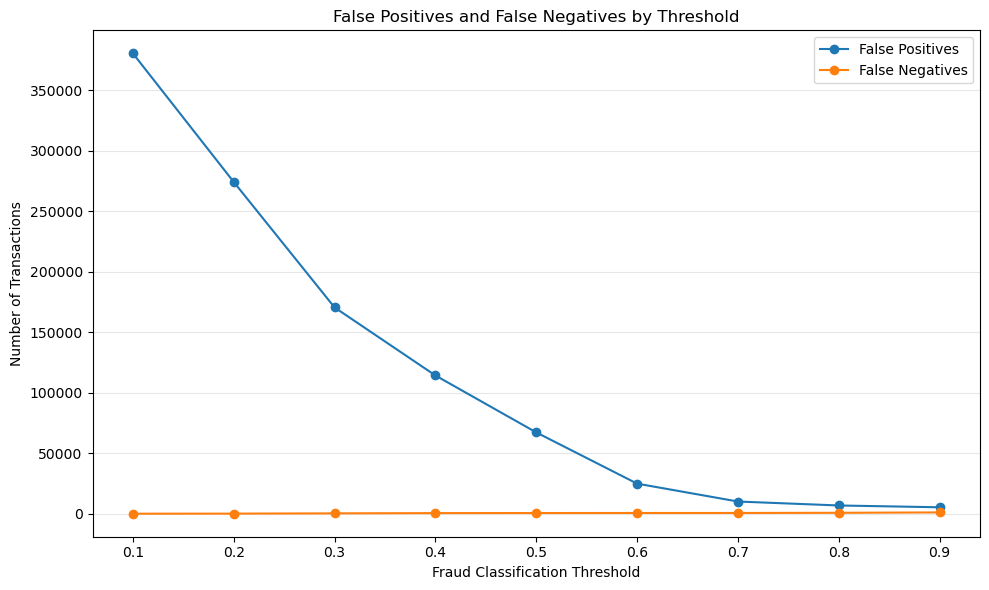

In [51]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_table["threshold"],
    threshold_table["false_positives"],
    marker="o",
    label="False Positives"
)

plt.plot(
    threshold_table["threshold"],
    threshold_table["false_negatives"],
    marker="o",
    label="False Negatives"
)

plt.title("False Positives and False Negatives by Threshold")
plt.xlabel("Fraud Classification Threshold")
plt.ylabel("Number of Transactions")
plt.xticks(thresholds)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../outputs/charts/figure_5_classification_errors_by_threshold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. False-Positive Deep Dive

        At the selected logistic-regression threshold, isolate legitimate transactions that were incorrectly flagged and examine amount, category, and hour patterns.


In [53]:
# Create predictions using the selected 0.70 threshold
selected_threshold = 0.70

selected_predictions = (
    logistic_probabilities >= selected_threshold
).astype(int)

# Create an analysis copy of the test data
false_positive_analysis = fraud_test.copy()

false_positive_analysis["predicted_fraud_probability"] = (
    logistic_probabilities
)

false_positive_analysis["predicted_class"] = (
    selected_predictions
)

# Identify legitimate transactions that were incorrectly flagged
false_positive_analysis["false_positive"] = (
    (false_positive_analysis["is_fraud"] == 0)
    & (false_positive_analysis["predicted_class"] == 1)
).astype(int)

print(
    false_positive_analysis["false_positive"]
    .value_counts()
)

print(
    "\nFalse-positive rate among legitimate transactions:"
)

legitimate_test_count = (
    false_positive_analysis["is_fraud"] == 0
).sum()

false_positive_count = (
    false_positive_analysis["false_positive"] == 1
).sum()

selected_fp_rate = (
    false_positive_count / legitimate_test_count * 100
)

print(f"{selected_fp_rate:.4f}%")

false_positive
0    545657
1     10062
Name: count, dtype: int64

False-positive rate among legitimate transactions:
1.8176%


In [55]:
# Keep only legitimate transactions
legitimate_analysis = false_positive_analysis[
    false_positive_analysis["is_fraud"] == 0
].copy()

fp_amount_summary = (
    legitimate_analysis
    .groupby("false_positive")["amt"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .rename(
        index={
            0: "Correctly Approved",
            1: "False Positive"
        }
    )
)

print(fp_amount_summary)

                     count        mean   median         std    min       max
false_positive                                                              
Correctly Approved  543512   57.000551   45.910   59.175931   1.00    679.54
False Positive       10062  640.935717  460.505  868.987156  93.76  22768.11


In [57]:
correctly_approved_amounts = legitimate_analysis.loc[
    legitimate_analysis["false_positive"] == 0,
    "amt"
]

false_positive_amounts = legitimate_analysis.loc[
    legitimate_analysis["false_positive"] == 1,
    "amt"
]

fp_amount_test = mannwhitneyu(
    correctly_approved_amounts,
    false_positive_amounts,
    alternative="two-sided"
)

print("False-positive amount comparison")
print("Mann-Whitney U statistic:", fp_amount_test.statistic)
print("P-value:", fp_amount_test.pvalue)

if fp_amount_test.pvalue < 0.05:
    print(
        "Reject the null hypothesis: transaction amounts differ "
        "between false positives and correctly approved transactions."
    )
else:
    print(
        "Fail to reject the null hypothesis: no significant "
        "transaction amount difference was detected."
    )

False-positive amount comparison
Mann-Whitney U statistic: 36700582.5
P-value: 0.0
Reject the null hypothesis: transaction amounts differ between false positives and correctly approved transactions.


In [59]:
fp_category_table = pd.crosstab(
    legitimate_analysis["category"],
    legitimate_analysis["false_positive"]
)

fp_category_chi2, fp_category_p, fp_category_dof, _ = (
    chi2_contingency(fp_category_table)
)

print("Transaction category and false-positive status")
print("Chi-square statistic:", fp_category_chi2)
print("Degrees of freedom:", fp_category_dof)
print("P-value:", fp_category_p)

if fp_category_p < 0.05:
    print(
        "Reject the null hypothesis: transaction category is "
        "associated with false-positive status."
    )
else:
    print(
        "Fail to reject the null hypothesis."
    )

Transaction category and false-positive status
Chi-square statistic: 21727.106553744583
Degrees of freedom: 13
P-value: 0.0
Reject the null hypothesis: transaction category is associated with false-positive status.


In [61]:
fp_hour_table = pd.crosstab(
    legitimate_analysis["transaction_hour"],
    legitimate_analysis["false_positive"]
)

fp_hour_chi2, fp_hour_p, fp_hour_dof, _ = (
    chi2_contingency(fp_hour_table)
)

print("Transaction hour and false-positive status")
print("Chi-square statistic:", fp_hour_chi2)
print("Degrees of freedom:", fp_hour_dof)
print("P-value:", fp_hour_p)

if fp_hour_p < 0.05:
    print(
        "Reject the null hypothesis: transaction hour is "
        "associated with false-positive status."
    )
else:
    print(
        "Fail to reject the null hypothesis."
    )

Transaction hour and false-positive status
Chi-square statistic: 791.8497399799323
Degrees of freedom: 23
P-value: 1.8325867529347229e-152
Reject the null hypothesis: transaction hour is associated with false-positive status.


In [63]:
# False-positive rate by transaction category
fp_category_analysis = (
    legitimate_analysis
    .groupby("category")
    .agg(
        legitimate_transactions=("false_positive", "size"),
        false_positives=("false_positive", "sum")
    )
    .reset_index()
)

fp_category_analysis["false_positive_rate_percent"] = (
    fp_category_analysis["false_positives"]
    / fp_category_analysis["legitimate_transactions"]
    * 100
)

fp_category_analysis = fp_category_analysis.sort_values(
    "false_positive_rate_percent",
    ascending=False
)

print("False-positive rate by category:")
print(fp_category_analysis.to_string(index=False))

False-positive rate by category:
      category  legitimate_transactions  false_positives  false_positive_rate_percent
        travel                    17409             2266                    13.016256
      misc_pos                    34502             2492                     7.222770
  shopping_pos                    49578             1154                     2.327645
   grocery_pos                    52068             1135                     2.179842
      misc_net                    27100              566                     2.088561
  shopping_net                    41273              836                     2.025537
 personal_care                    39257              569                     1.449423
     kids_pets                    48627              507                     1.042631
health_fitness                    36622              180                     0.491508
   food_dining                    39214              154                     0.392717
 entertainment       

In [65]:
# False-positive rate by transaction hour
fp_hour_analysis = (
    legitimate_analysis
    .groupby("transaction_hour")
    .agg(
        legitimate_transactions=("false_positive", "size"),
        false_positives=("false_positive", "sum")
    )
    .reset_index()
)

fp_hour_analysis["false_positive_rate_percent"] = (
    fp_hour_analysis["false_positives"]
    / fp_hour_analysis["legitimate_transactions"]
    * 100
)

fp_hour_analysis = fp_hour_analysis.sort_values(
    "transaction_hour"
)

print("False-positive rate by hour:")
print(fp_hour_analysis.to_string(index=False))

False-positive rate by hour:
 transaction_hour  legitimate_transactions  false_positives  false_positive_rate_percent
                0                    17965              149                     0.829390
                1                    18292              174                     0.951236
                2                    17972              172                     0.957044
                3                    18005              184                     1.021938
                4                    18060              198                     1.096346
                5                    17897              211                     1.178969
                6                    18092              237                     1.309971
                7                    18082              257                     1.421303
                8                    17983              342                     1.901796
                9                    18032              410                     2

In [67]:
fp_category_analysis.to_csv(
    "../outputs/tables/false_positive_rate_by_category.csv",
    index=False
)

fp_hour_analysis.to_csv(
    "../outputs/tables/false_positive_rate_by_hour.csv",
    index=False
)

fp_amount_summary.to_csv(
    "../outputs/tables/false_positive_amount_summary.csv"
)

print("False-positive analysis tables saved successfully.")

False-positive analysis tables saved successfully.


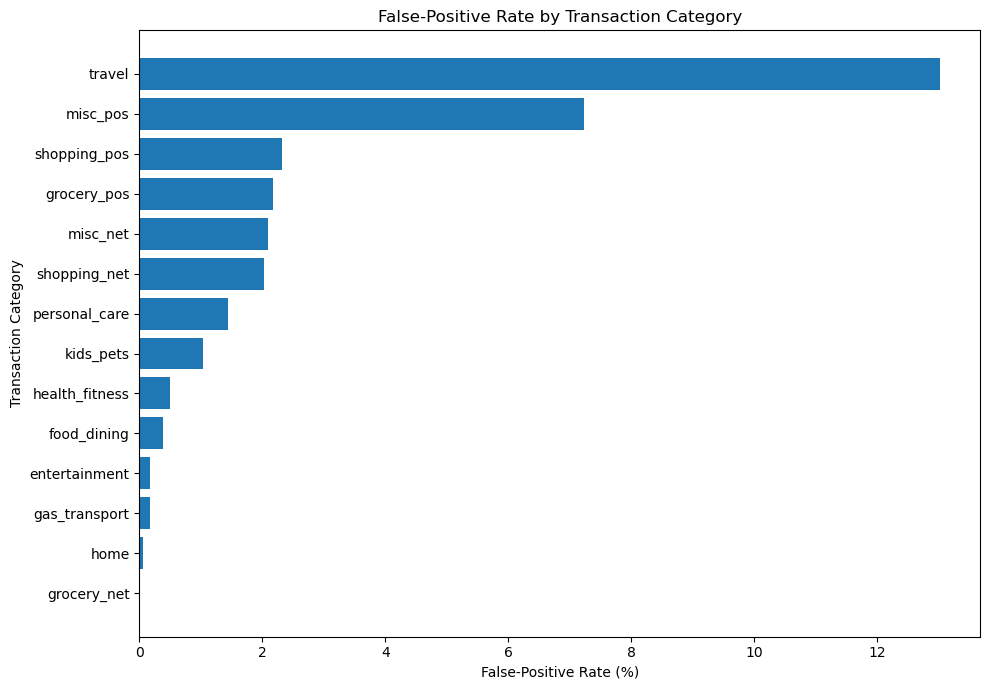

In [69]:
# Figure 6: False-positive rate by category
fp_category_chart = fp_category_analysis.sort_values(
    "false_positive_rate_percent",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    fp_category_chart["category"],
    fp_category_chart["false_positive_rate_percent"]
)

plt.title("False-Positive Rate by Transaction Category")
plt.xlabel("False-Positive Rate (%)")
plt.ylabel("Transaction Category")
plt.tight_layout()

plt.savefig(
    "../outputs/charts/figure_6_false_positive_rate_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

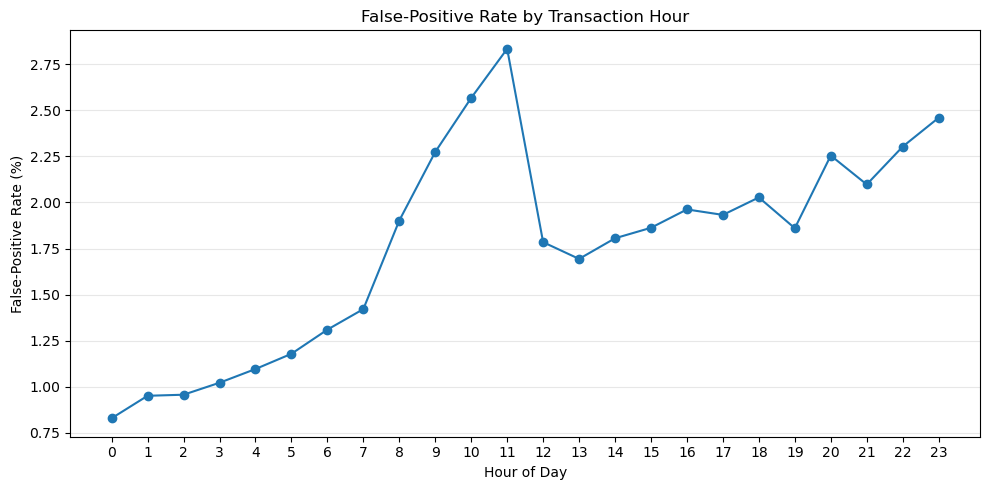

In [71]:
# Figure 7: False-positive rate by hour
plt.figure(figsize=(10, 5))

plt.plot(
    fp_hour_analysis["transaction_hour"],
    fp_hour_analysis["false_positive_rate_percent"],
    marker="o"
)

plt.title("False-Positive Rate by Transaction Hour")
plt.xlabel("Hour of Day")
plt.ylabel("False-Positive Rate (%)")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../outputs/charts/figure_7_false_positive_rate_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11. Histogram-Based Gradient Boosting

        Train a nonlinear model to capture interactions and patterns that logistic regression may not represent effectively.


In [73]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [75]:
# Preprocessing for the second model
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median"))
                ]
            ),
            numeric_features
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "encoder",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False
                        )
                    )
                ]
            ),
            categorical_features
        )
    ]
)

gradient_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "classifier",
            HistGradientBoostingClassifier(
                learning_rate=0.08,
                max_iter=150,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                random_state=42
            )
        )
    ]
)

print("Training gradient boosting model...")
gradient_model.fit(X_train, y_train)
print("Gradient boosting training complete.")

Training gradient boosting model...
Gradient boosting training complete.


In [77]:
gradient_probabilities = gradient_model.predict_proba(X_test)[:, 1]

gradient_predictions = (
    gradient_probabilities >= 0.50
).astype(int)

tn_gb, fp_gb, fn_gb, tp_gb = confusion_matrix(
    y_test,
    gradient_predictions
).ravel()

gradient_accuracy = accuracy_score(
    y_test,
    gradient_predictions
)

gradient_precision = precision_score(
    y_test,
    gradient_predictions,
    zero_division=0
)

gradient_recall = recall_score(
    y_test,
    gradient_predictions,
    zero_division=0
)

gradient_f1 = f1_score(
    y_test,
    gradient_predictions,
    zero_division=0
)

gradient_roc_auc = roc_auc_score(
    y_test,
    gradient_probabilities
)

gradient_pr_auc = average_precision_score(
    y_test,
    gradient_probabilities
)

print("Gradient Boosting Results at Threshold 0.50")
print("-------------------------------------------")
print("True negatives:", tn_gb)
print("False positives:", fp_gb)
print("False negatives:", fn_gb)
print("True positives:", tp_gb)

print(f"\nAccuracy:  {gradient_accuracy:.4f}")
print(f"Precision: {gradient_precision:.4f}")
print(f"Recall:    {gradient_recall:.4f}")
print(f"F1-score:  {gradient_f1:.4f}")
print(f"ROC-AUC:   {gradient_roc_auc:.4f}")
print(f"PR-AUC:    {gradient_pr_auc:.4f}")

Gradient Boosting Results at Threshold 0.50
-------------------------------------------
True negatives: 553411
False positives: 163
False negatives: 468
True positives: 1677

Accuracy:  0.9989
Precision: 0.9114
Recall:    0.7818
F1-score:  0.8417
ROC-AUC:   0.9972
PR-AUC:    0.8909


## 12. Model Performance Comparison

        Compare logistic regression and gradient boosting at the default 0.50 threshold using confusion-matrix outcomes and imbalance-sensitive metrics.


In [79]:
model_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "threshold": 0.50,
        "true_negatives": 486370,
        "false_positives": 67204,
        "false_negatives": 556,
        "true_positives": 1589,
        "accuracy": logistic_accuracy,
        "precision": logistic_precision,
        "recall": logistic_recall,
        "f1_score": logistic_f1,
        "roc_auc": logistic_roc_auc,
        "pr_auc": logistic_pr_auc
    },
    {
        "model": "Gradient Boosting",
        "threshold": 0.50,
        "true_negatives": tn_gb,
        "false_positives": fp_gb,
        "false_negatives": fn_gb,
        "true_positives": tp_gb,
        "accuracy": gradient_accuracy,
        "precision": gradient_precision,
        "recall": gradient_recall,
        "f1_score": gradient_f1,
        "roc_auc": gradient_roc_auc,
        "pr_auc": gradient_pr_auc
    }
])

print(model_comparison.to_string(index=False))

model_comparison.to_csv(
    "../outputs/tables/model_comparison.csv",
    index=False
)

print("\nModel comparison saved successfully.")

              model  threshold  true_negatives  false_positives  false_negatives  true_positives  accuracy  precision   recall  f1_score  roc_auc   pr_auc
Logistic Regression        0.5          486370            67204              556            1589  0.878068   0.023098 0.740793  0.044800 0.907701 0.120588
  Gradient Boosting        0.5          553411              163              468            1677  0.998865   0.911413 0.781818  0.841656 0.997187 0.890949

Model comparison saved successfully.


## 13. Gradient Boosting Threshold Analysis

        Evaluate the gradient-boosting model across the same decision thresholds used for logistic regression.


In [81]:
gradient_threshold_results = []

for threshold in thresholds:
    predictions = (
        gradient_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    review_volume = tp + fp
    false_positive_rate = fp / (fp + tn)

    gradient_threshold_results.append({
        "threshold": threshold,
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "false_positive_rate": false_positive_rate,
        "manual_review_volume": review_volume
    })

gradient_threshold_table = pd.DataFrame(
    gradient_threshold_results
)

print(
    gradient_threshold_table[
        [
            "threshold",
            "false_positives",
            "false_negatives",
            "true_positives",
            "precision",
            "recall",
            "f1_score",
            "false_positive_rate",
            "manual_review_volume"
        ]
    ].to_string(index=False)
)

 threshold  false_positives  false_negatives  true_positives  precision   recall  f1_score  false_positive_rate  manual_review_volume
       0.1             1173              258            1887   0.616667 0.879720  0.725072             0.002119                  3060
       0.2              522              363            1782   0.773438 0.830769  0.801079             0.000943                  2304
       0.3              286              409            1736   0.858556 0.809324  0.833213             0.000517                  2022
       0.4              215              433            1712   0.888428 0.798135  0.840864             0.000388                  1927
       0.5              163              468            1677   0.911413 0.781818  0.841656             0.000294                  1840
       0.6              111              513            1632   0.936317 0.760839  0.839506             0.000201                  1743
       0.7               74              576            1569  

In [83]:
gradient_threshold_table.to_csv(
    "../outputs/tables/gradient_boosting_threshold_analysis.csv",
    index=False
)

print("Gradient boosting threshold analysis saved successfully.")

Gradient boosting threshold analysis saved successfully.


## 14. Gradient Boosting Cost Analysis

        Apply the same cost scenarios to identify the lowest-cost threshold for the stronger model.


In [85]:
gradient_cost_results = []

for threshold in thresholds:
    predictions = (
        gradient_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    false_negative_mask = (
        (y_test.values == 1) &
        (predictions == 0)
    )

    missed_fraud_amount = fraud_test.loc[
        false_negative_mask,
        "amt"
    ].sum()

    for scenario_name, assumptions in cost_scenarios.items():
        false_positive_cost = (
            fp * assumptions["false_positive_cost"]
        )

        false_negative_cost = (
            missed_fraud_amount
            * assumptions["false_negative_multiplier"]
        )

        total_cost = (
            false_positive_cost
            + false_negative_cost
        )

        gradient_cost_results.append({
            "model": "Gradient Boosting",
            "scenario": scenario_name,
            "threshold": threshold,
            "false_positives": fp,
            "false_negatives": fn,
            "true_positives": tp,
            "missed_fraud_amount": missed_fraud_amount,
            "estimated_false_positive_cost": false_positive_cost,
            "estimated_false_negative_cost": false_negative_cost,
            "estimated_total_cost": total_cost
        })

gradient_cost_table = pd.DataFrame(
    gradient_cost_results
)

print(
    gradient_cost_table[
        [
            "scenario",
            "threshold",
            "false_positives",
            "false_negatives",
            "true_positives",
            "missed_fraud_amount",
            "estimated_false_positive_cost",
            "estimated_false_negative_cost",
            "estimated_total_cost"
        ]
    ].to_string(index=False)
)

     scenario  threshold  false_positives  false_negatives  true_positives  missed_fraud_amount  estimated_false_positive_cost  estimated_false_negative_cost  estimated_total_cost
     Low Cost        0.1             1173              258            1887             50531.52                           5865                      50531.520             56396.520
Moderate Cost        0.1             1173              258            1887             50531.52                          17595                      75797.280             93392.280
    High Cost        0.1             1173              258            1887             50531.52                          35190                     101063.040            136253.040
     Low Cost        0.2              522              363            1782             69872.52                           2610                      69872.520             72482.520
Moderate Cost        0.2              522              363            1782             69872.52     

In [87]:
best_gradient_cost_thresholds = (
    gradient_cost_table
    .loc[
        gradient_cost_table.groupby("scenario")[
            "estimated_total_cost"
        ].idxmin()
    ]
    .sort_values("scenario")
)

print("Lowest-cost gradient boosting threshold by scenario:")
print(
    best_gradient_cost_thresholds[
        [
            "scenario",
            "threshold",
            "false_positives",
            "false_negatives",
            "true_positives",
            "missed_fraud_amount",
            "estimated_total_cost"
        ]
    ].to_string(index=False)
)

Lowest-cost gradient boosting threshold by scenario:
     scenario  threshold  false_positives  false_negatives  true_positives  missed_fraud_amount  estimated_total_cost
    High Cost        0.1             1173              258            1887             50531.52             136253.04
     Low Cost        0.1             1173              258            1887             50531.52              56396.52
Moderate Cost        0.1             1173              258            1887             50531.52              93392.28


In [89]:
gradient_cost_table.to_csv(
    "../outputs/tables/gradient_boosting_cost_scenario_analysis.csv",
    index=False
)

best_gradient_cost_thresholds.to_csv(
    "../outputs/tables/gradient_boosting_best_threshold_by_cost_scenario.csv",
    index=False
)

print("Gradient boosting cost tables saved successfully.")

Gradient boosting cost tables saved successfully.


## 15. Recommended Model and Threshold by Cost Scenario

        Compare the best logistic-regression and gradient-boosting outcomes to identify the lowest estimated total cost under each scenario.


In [91]:
# Best logistic regression cost result by scenario
best_logistic_costs = best_cost_thresholds.copy()
best_logistic_costs["model"] = "Logistic Regression"

# Best gradient boosting cost result by scenario
best_gradient_costs = best_gradient_cost_thresholds.copy()
best_gradient_costs["model"] = "Gradient Boosting"

# Align the columns
comparison_columns = [
    "model",
    "scenario",
    "threshold",
    "false_positives",
    "false_negatives",
    "missed_fraud_amount",
    "estimated_total_cost"
]

best_model_cost_comparison = pd.concat(
    [
        best_logistic_costs[comparison_columns],
        best_gradient_costs[comparison_columns]
    ],
    ignore_index=True
)

best_model_cost_comparison = best_model_cost_comparison.sort_values(
    ["scenario", "model"]
)

print("Best cost result by model and scenario:")
print(
    best_model_cost_comparison.to_string(index=False)
)

Best cost result by model and scenario:
              model      scenario  threshold  false_positives  false_negatives  missed_fraud_amount  estimated_total_cost
  Gradient Boosting     High Cost        0.1             1173              258             50531.52            136253.040
Logistic Regression     High Cost        0.8             6802              748             78187.67            360435.340
  Gradient Boosting      Low Cost        0.1             1173              258             50531.52             56396.520
Logistic Regression      Low Cost        0.7            10062              599             32055.03             82365.030
  Gradient Boosting Moderate Cost        0.1             1173              258             50531.52             93392.280
Logistic Regression Moderate Cost        0.7            10062              599             32055.03            199012.545


In [93]:
best_model_cost_comparison.to_csv(
    "../outputs/tables/best_model_cost_comparison.csv",
    index=False
)

print("Best model cost comparison saved successfully.")

Best model cost comparison saved successfully.


## 16. Final Visual Comparisons

        Generate the model-cost and model-performance figures used in the final paper and presentation.


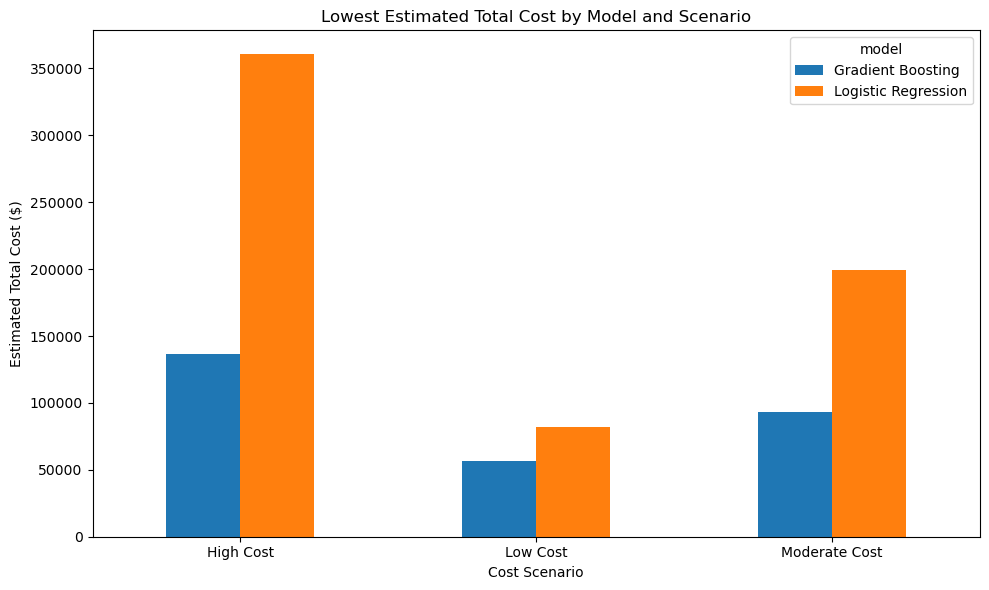

In [95]:
cost_pivot = best_model_cost_comparison.pivot(
    index="scenario",
    columns="model",
    values="estimated_total_cost"
)

cost_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Lowest Estimated Total Cost by Model and Scenario")
plt.xlabel("Cost Scenario")
plt.ylabel("Estimated Total Cost ($)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "../outputs/charts/figure_8_best_model_cost_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

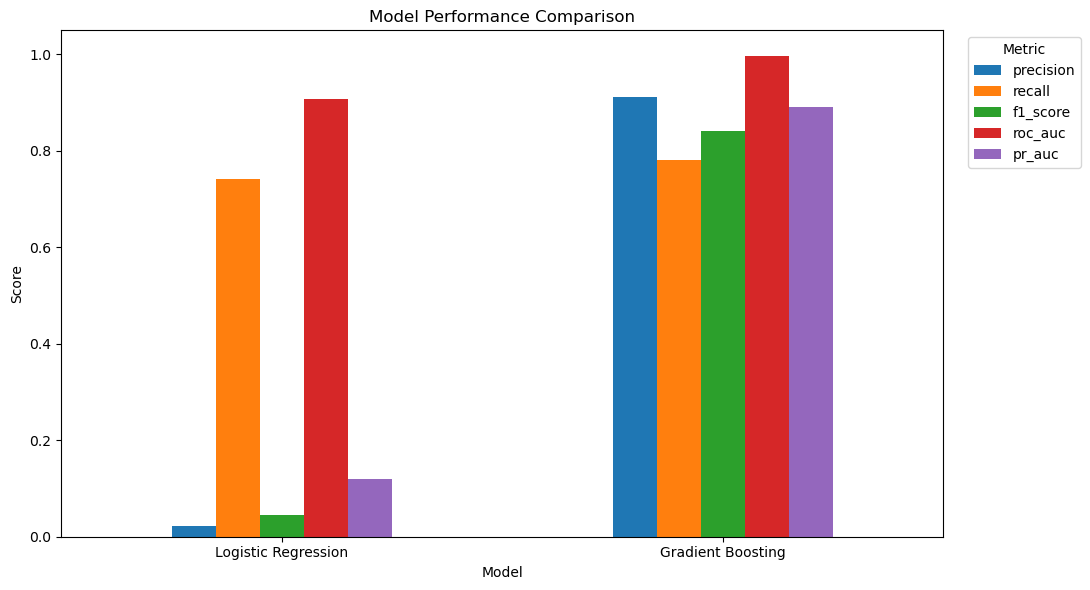

In [97]:
metric_comparison = model_comparison.set_index("model")[
    [
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc"
    ]
]

metric_comparison.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    "../outputs/charts/figure_9_model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 17. Hypothesis Decisions

        Summarize the primary evidence and final decision for each null hypothesis.


In [99]:
hypothesis_summary = pd.DataFrame([
    {
        "hypothesis": "H01",
        "null_statement": (
            "Changes in classification threshold do not significantly "
            "change false positives, fraud detection, or estimated cost."
        ),
        "main_evidence": (
            "Threshold changes produced large differences in false positives, "
            "false negatives, recall, review volume, and estimated total cost."
        ),
        "decision": "Reject the null hypothesis"
    },
    {
        "hypothesis": "H02",
        "null_statement": (
            "Transaction characteristics are not significantly associated "
            "with false-positive status."
        ),
        "main_evidence": (
            "Amount differed significantly (p < .001); category was associated "
            "with false positives, chi-square(13) = 21,727.11, p < .001; "
            "hour was associated with false positives, "
            "chi-square(23) = 791.85, p < .001."
        ),
        "decision": "Reject the null hypothesis"
    },
    {
        "hypothesis": "H03",
        "null_statement": (
            "Cost-based scenario analysis does not produce meaningful "
            "differences across thresholds."
        ),
        "main_evidence": (
            "The lowest-cost threshold changed by model and cost assumptions. "
            "Gradient boosting also produced lower estimated total cost than "
            "logistic regression in every scenario."
        ),
        "decision": "Reject the null hypothesis"
    }
])

print(hypothesis_summary.to_string(index=False))

hypothesis_summary.to_csv(
    "../outputs/tables/hypothesis_summary.csv",
    index=False
)

print("\nHypothesis summary saved successfully.")

hypothesis                                                                                                       null_statement                                                                                                                                                                                              main_evidence                   decision
       H01 Changes in classification threshold do not significantly change false positives, fraud detection, or estimated cost.                                                                         Threshold changes produced large differences in false positives, false negatives, recall, review volume, and estimated total cost. Reject the null hypothesis
       H02                             Transaction characteristics are not significantly associated with false-positive status. Amount differed significantly (p < .001); category was associated with false positives, chi-square(13) = 21,727.11, p < .001; hour was associated with false